# Chapter 3 — Big Data

**Course 888102 — International College of Digital Innovation, Chiang Mai University**

> *"Data is the new oil"* — and like oil, it is only valuable once it is refined.

That comparison is worth taking literally. Crude oil sitting in the ground helps nobody; it has to be
extracted, transported, refined, and distributed before it powers anything. Raw data behaves the same way. A
database nobody has analyzed is a cost, not an asset — and, unlike oil, it also carries legal risk and a
storage bill while it sits there.

Chapter 1 defined big data loosely as "data at a scale where the tools break." This chapter makes that
precise, using the **V's**, and then asks the two questions that follow from it: *can we trust this data?* and
*what can we actually do with it?*

### Learning objectives

By the end of this chapter you should be able to:

1. **Define big data** precisely — understand what makes data "big" rather than merely large.
2. **Explain the V's** — volume, velocity, variety, veracity (and value) — and recognize which one is causing
   trouble in a given situation.
3. **Know the analytics types** — descriptive, diagnostic, predictive, prescriptive — and place any business
   question on that ladder.

### How this notebook is organized

| Section | What it covers |
|---|---|
| 1 | What big data is, and the "new oil" metaphor |
| 2 | The V's: volume, velocity, variety, veracity — and why "value" is the fifth |
| 3 | Data quality dimensions: auditing a dataset on six measurable axes |
| 4 | Analytics maturity: hindsight → insight → foresight, worked end to end |
| 5 | Correlation is not causation — confounders, Simpson's paradox, and spurious correlation |
| 6 | Where the V's send you architecturally: batch vs. stream, lake vs. warehouse |
| 7–9 | Glossary, self-check quiz, summary |
| 10 | Graded homework 📝 |

In [1]:
# Run this cell first — everything below depends on it.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.autolayout"] = True
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

rng = np.random.default_rng(888102)   # fixed seed: identical numbers for every student

print("Ready. pandas", pd.__version__)

Ready. pandas 3.0.5


---
## 1. What is big data?

**Big data** is a massive amount of data sets that cannot be stored, processed, or analyzed using traditional
tools.

The defining trait is not the quantity. It is that **the tools themselves must change**. A dataset is "big"
relative to the machinery you have and the question you are asking — the same 500 GB is routine for a cloud
warehouse and impossible for a laptop spreadsheet.

The V's on the following pages are how that "must change" gets characterized precisely. Each V names a
*different reason* the ordinary approach fails:

| V | The ordinary approach fails because… | The fix is a different… |
|---|---|---|
| **Volume** | …it will not fit, or the scan takes days | storage and compute model (distributed) |
| **Velocity** | …new data arrives faster than you can process the last batch | processing model (streaming) |
| **Variety** | …it does not fit in rows and columns at all | data model (documents, text, images) |
| **Veracity** | …the data is wrong, and volume hides the wrongness | quality process (validation, monitoring) |
| **Value** | …you spent a fortune and learned nothing | question (start with the decision) |

Notice that only the first two are about size. This is the most common misunderstanding of the term: people
hear "big data" and think about terabytes, when in practice the V that ruins most projects is veracity.

---
## 2. The V's of big data

### 2.1 Volume — big data is large in volume

The scale runs from bytes to yottabytes (Chapter 1), fed by the three primary sources:

- **Social data** — collected from users' public activity on social networks.
- **Machine data** — automatically generated by the activities of networked machines.
- **Transactional data** — generated by all the daily transactions taking place, online and offline.

Volume is the V people find easiest to picture and the one that is, in practice, the easiest to solve — you
can buy your way out of a volume problem. What makes volume interesting is how quickly an innocuous-sounding
requirement turns into one.

In [2]:
# How fast does an innocent-sounding requirement become a volume problem?
scenarios = pd.DataFrame([
    ("One temperature sensor, 1 reading/minute",            1,          1/60,   16),
    ("A 500-room hotel, 1 sensor per room",                 500,        1/60,   16),
    ("10,000 delivery scooters, GPS every second",          10_000,     1,      48),
    ("A city of 200,000 smart electricity meters",          200_000,    1/900,  32),
    ("2 million users, 20 app events each per day",         2_000_000,  20/86400, 250),
], columns=["Scenario", "Devices", "Readings per second each", "Bytes per reading"])

scenarios["Rows per day"] = (scenarios["Devices"] * scenarios["Readings per second each"] * 86_400)
scenarios["GB per day"] = scenarios["Rows per day"] * scenarios["Bytes per reading"] / 1e9
scenarios["TB per year"] = scenarios["GB per day"] * 365 / 1000

display_table = scenarios[["Scenario", "Rows per day", "GB per day", "TB per year"]].copy()
display_table["Rows per day"] = display_table["Rows per day"].map("{:,.0f}".format)
display_table["GB per day"] = display_table["GB per day"].map("{:,.2f}".format)
display_table["TB per year"] = display_table["TB per year"].map("{:,.2f}".format)
display_table

,Scenario,Rows per day,GB per day,TB per year
0,"One temperature sensor, 1 reading/minute","1,440",0.00,0.00
1,"A 500-room hotel, 1 sensor per room","720,000",0.01,0.00
2,"10,000 delivery scooters, GPS every second","864,000,000",41.47,15.14
3,"A city of 200,000 smart electricity meters","19,200,000",0.61,0.22
4,"2 million users, 20 app events each per day","40,000,000",10.00,3.65


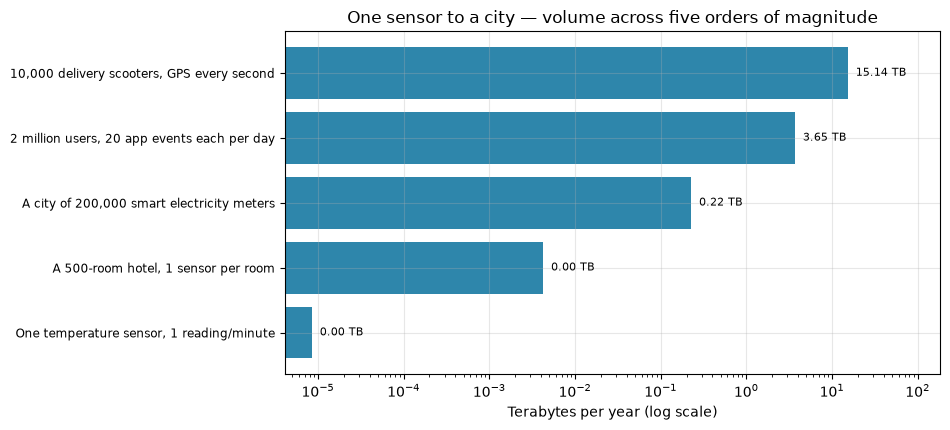

In [3]:
fig, ax = plt.subplots(figsize=(9.6, 4.4))
order = scenarios.sort_values("TB per year")
ax.barh(range(len(order)), order["TB per year"], color="#2E86AB")
ax.set_yticks(range(len(order)), [s[:44] for s in order["Scenario"]], fontsize=8.5)
ax.set_xscale("log")
ax.set_xlabel("Terabytes per year (log scale)")
ax.set_title("One sensor to a city — volume across five orders of magnitude")
for i, value in enumerate(order["TB per year"]):
    ax.text(value * 1.25, i, f"{value:,.2f} TB", va="center", fontsize=8)
ax.set_xlim(right=order["TB per year"].max() * 12)
plt.show()

**How to read it:** one sensor produces well under a gigabyte a year — you could keep it in a text file
forever. The same *kind* of data, from a whole city's meters, is measured in terabytes per year, and the app
telemetry row is larger still. Nothing changed conceptually between the first row and the last; only the
multiplier did, and that multiplier is the entire volume problem.

Note also what dominates: **rows per day matters more than bytes per row.** The scooter fleet writes small
records very often and beats the meter city, which writes bigger records rarely. When people try to solve a
volume problem by shrinking the record, they are usually optimizing the wrong term.

> ✏️ **Try it:** add a row for Chiang Mai's traffic cameras — say 400 cameras, one 200 KB image every 5
> seconds. Where does it land on the chart, and which term (rows or bytes) put it there?

### 2.2 Velocity — how fast data arrives

Velocity is **not** "how much data exists" but **how fast new data is generated** and how quickly you must
respond to it.

**Real-world example.** Google Maps traffic takes advantage of the GPS of commuters already on the road,
analyzing it in real time to present the most streamlined route. The value of that analysis decays in minutes
— a perfect traffic report about 20 minutes ago is worthless.

**Network evolution.** From 1G to 5G, each generation of mobile network exists specifically to raise the
velocity ceiling. Faster networks make higher-velocity applications possible, which is why the two histories
track each other so closely.

In [4]:
# Each mobile generation raised the velocity ceiling, and new application classes followed.
networks = pd.DataFrame([
    ("1G",  1980, 0.0024,  "—",       "Analog voice only"),
    ("2G",  1991, 0.064,   "~500 ms", "Text messages, basic email"),
    ("3G",  2001, 2.0,     "~100 ms", "Mobile web, photo sharing, first video calls"),
    ("4G",  2009, 100.0,   "~50 ms",  "HD video streaming, ride-hailing, live maps"),
    ("5G",  2019, 10_000.0,"~1 ms",   "IoT at scale, autonomous vehicles, AR"),
], columns=["Generation", "Year", "Peak speed (Mbit/s)", "Typical latency", "What it made possible"])

networks

,Generation,Year,Peak speed (Mbit/s),Typical latency,What it made possible
0,1G,1980,0.0024,—,Analog voice only
1,2G,1991,0.0640,~500 ms,"Text messages, basic email"
2,3G,2001,2.0000,~100 ms,"Mobile web, photo sharing, first video calls"
3,4G,2009,100.0000,~50 ms,"HD video streaming, ride-hailing, live maps"
4,5G,2019,10000.0000,~1 ms,"IoT at scale, autonomous vehicles, AR"


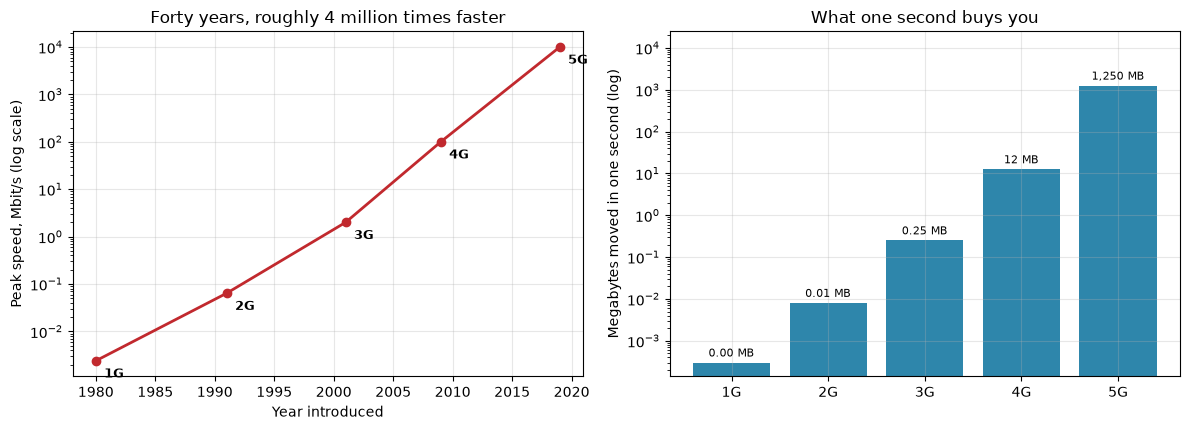

In [5]:
fig, (ax_speed, ax_apps) = plt.subplots(1, 2, figsize=(12, 4.4))

ax_speed.plot(networks["Year"], networks["Peak speed (Mbit/s)"], marker="o",
              color="#C1292E", linewidth=2)
for _, row in networks.iterrows():
    ax_speed.annotate(row["Generation"], (row["Year"], row["Peak speed (Mbit/s)"]),
                      textcoords="offset points", xytext=(6, -12), fontsize=9, fontweight="bold")
ax_speed.set_yscale("log")
ax_speed.set_xlabel("Year introduced")
ax_speed.set_ylabel("Peak speed, Mbit/s (log scale)")
ax_speed.set_title("Forty years, roughly 4 million times faster")

# How much data can one second of each generation move?
one_second_mb = networks["Peak speed (Mbit/s)"] / 8
ax_apps.bar(networks["Generation"], one_second_mb, color="#2E86AB")
ax_apps.set_yscale("log")
ax_apps.set_ylabel("Megabytes moved in one second (log)")
ax_apps.set_title("What one second buys you")
for gen, value in zip(networks["Generation"], one_second_mb):
    ax_apps.text(gen, value * 1.4, f"{value:,.2f} MB" if value < 1 else f"{value:,.0f} MB",
                 ha="center", fontsize=8)
ax_apps.set_ylim(top=one_second_mb.max() * 20)

plt.show()

**How to read it:** both panels use a log scale, and the left one is close to a straight line — mobile
bandwidth has grown at a roughly constant *multiplicative* rate for forty years, the same pattern as the data
volume curve in Chapter 1.

The right panel translates that into something concrete. One second of 2G moves 8 KB — about three lines of
this paragraph. One second of 5G moves more than a gigabyte. **That is the velocity ceiling**, and every
application in the last column of the table exists because the ceiling rose enough to permit it. Ride-hailing
was not a clever idea nobody had in 2001; it was an idea that could not run on 3G latency.

#### Batch, micro-batch, and stream

Velocity forces an architectural choice, and it is worth naming the three options now because Chapter 5 will
assume you know them.

| Mode | How it works | Latency | Good for |
|---|---|---|---|
| **Batch** | Collect for a period, then process all of it at once | Hours to a day | Monthly reports, payroll, model training |
| **Micro-batch** | The same, but in small windows | Seconds to minutes | Dashboards, near-real-time metrics |
| **Stream** | Process each record as it arrives | Milliseconds | Fraud blocking, traffic routing, alerting |

The trade-off is not subtle: streaming costs far more to build and operate, and it is only worth it when the
value of an answer **decays quickly**. The cell below makes that decay concrete.

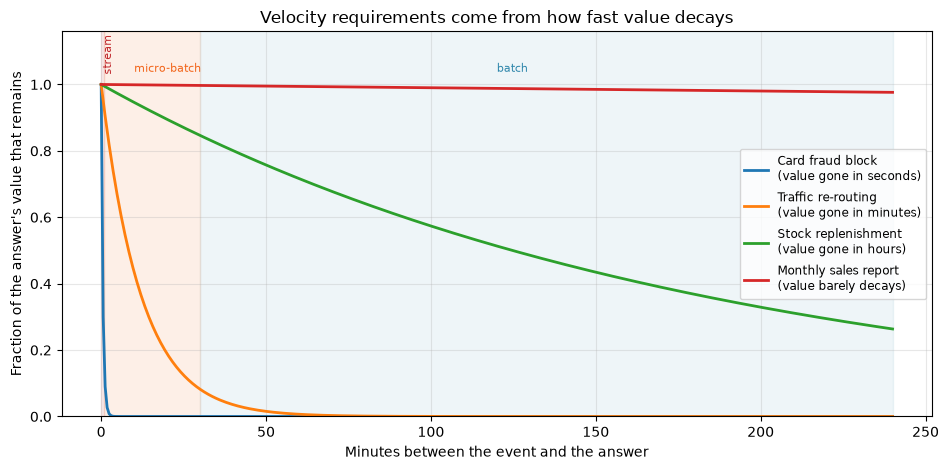

In [6]:
# How much is an answer worth, as a function of how late it is?
minutes = np.linspace(0, 240, 400)

use_cases = {
    "Card fraud block\n(value gone in seconds)": np.exp(-minutes / 0.5),
    "Traffic re-routing\n(value gone in minutes)": np.exp(-minutes / 12),
    "Stock replenishment\n(value gone in hours)": np.exp(-minutes / 180),
    "Monthly sales report\n(value barely decays)": np.exp(-minutes / 10_000),
}

fig, ax = plt.subplots(figsize=(9.6, 4.8))
for label, value in use_cases.items():
    ax.plot(minutes, value, linewidth=2, label=label)
ax.axvspan(0, 1, color="#C1292E", alpha=0.10)
ax.axvspan(1, 30, color="#F26419", alpha=0.10)
ax.axvspan(30, 240, color="#2E86AB", alpha=0.08)
ax.text(0.4, 1.03, "stream", fontsize=8, color="#C1292E", rotation=90, va="bottom")
ax.text(10, 1.03, "micro-batch", fontsize=8, color="#F26419", va="bottom")
ax.text(120, 1.03, "batch", fontsize=8, color="#2E86AB", va="bottom")
ax.set_xlabel("Minutes between the event and the answer")
ax.set_ylabel("Fraction of the answer's value that remains")
ax.set_title("Velocity requirements come from how fast value decays")
ax.set_ylim(0, 1.16)
ax.legend(fontsize=8.5)
plt.show()

**How to read it:** the four curves have the same shape and wildly different time constants. A fraud decision
that arrives one minute late is worthless — the money has already gone. A traffic re-route is half-useless
after ten minutes. A monthly sales report is essentially as valuable on Tuesday as on Monday.

**So the engineering question "do we need streaming?" is really a business question: how fast does the answer
rot?** Teams that skip that question tend to build expensive streaming pipelines to feed dashboards that
nobody looks at more than once a day.

### 2.3 Variety — the same person, three different forms

**Variety** is the diversity of data in a collection: **structured**, **semi-structured**, and
**unstructured**. The lecture makes the point with one person's details, recorded three ways.

In [7]:
# The same "Rachel Wolff" record, in three varieties.

# STRUCTURED — a fixed schema, fits straight into a relational table.
structured = pd.DataFrame({"FirstName": ["Rachel"], "LastName": ["Wolff"]})
print("STRUCTURED (a table row):")
print(structured.to_string(index=False))

# SEMI-STRUCTURED — tagged, self-describing, but no fixed schema. Note 'hobbies' is a nested list.
semi_structured = {"FirstName": "Rachel", "LastName": "Wolff", "hobbies": ["diving", "chess"]}
print("\nSEMI-STRUCTURED (JSON):")
print(json.dumps(semi_structured, indent=2))

# UNSTRUCTURED — free text. No fields at all.
unstructured = "Hey, it's Rachel Wolff here! Just got back from diving, can't wait for chess night :)"
print("\nUNSTRUCTURED (free text):")
print(unstructured)

STRUCTURED (a table row):
FirstName LastName
   Rachel    Wolff

SEMI-STRUCTURED (JSON):
{
  "FirstName": "Rachel",
  "LastName": "Wolff",
  "hobbies": [
    "diving",
    "chess"
  ]
}

UNSTRUCTURED (free text):
Hey, it's Rachel Wolff here! Just got back from diving, can't wait for chess night :)


**How to read it:** all three describe the same person, and the difficulty of getting a name out of them
differs by orders of magnitude. Let's actually try.

In [8]:
# Extracting "first name" from each variety — the effort tells you the whole story.
import re

# 1. Structured: it is already a field.
print("Structured   ->", structured.loc[0, "FirstName"])

# 2. Semi-structured: one lookup by key. Needs a parser, but the key is right there.
print("Semi-struct. ->", semi_structured["FirstName"])

# 3. Unstructured: we must guess at a pattern, and the guess is fragile.
match = re.search(r"it's ([A-Z][a-z]+) ([A-Z][a-z]+)", unstructured)
print("Unstructured ->", match.group(1) if match else "NOT FOUND")

# And here is why the guess is fragile — the same fact, phrased differently:
variants = [
    "Hey, it's Rachel Wolff here! Just got back from diving.",
    "Hi all — Rachel here (Wolff), back from a dive trip.",
    "rachel wolff reporting in after diving :)",
    "Just got back from diving! — R. Wolff",
]
print("\nThe same regular expression on four natural phrasings of the same fact:")
for text in variants:
    found = re.search(r"it's ([A-Z][a-z]+) ([A-Z][a-z]+)", text)
    print(f"  {'OK  ' if found else 'FAIL'}  {text}")

Structured   -> Rachel
Semi-struct. -> Rachel
Unstructured -> Rachel

The same regular expression on four natural phrasings of the same fact:
  OK    Hey, it's Rachel Wolff here! Just got back from diving.
  FAIL  Hi all — Rachel here (Wolff), back from a dive trip.
  FAIL  rachel wolff reporting in after diving :)
  FAIL  Just got back from diving! — R. Wolff


**How to read it:** the pattern works on exactly the sentence it was written for and fails on three equally
ordinary phrasings of the same fact. That is not a bad regular expression — it is the nature of unstructured
data. There is no schema to rely on, so every extraction is a guess about how humans write, and humans write
in unlimited ways.

This is why the industry's rule of thumb — commonly quoted as **roughly 80% of enterprise data is
unstructured** — is such an uncomfortable statistic. The large majority of what organizations hold is in the
form that is hardest to use. Chapter 12 (Text Mining) is entirely about attacking that 80%.

| Variety | Schema | Where it lives | Effort to analyze |
|---|---|---|---|
| **Structured** | Fixed, defined before the data arrives | Relational database, CSV, spreadsheet | Low — query it directly |
| **Semi-structured** | Self-describing, flexible per record | JSON, XML, document stores, log files | Medium — parse, then flatten |
| **Unstructured** | None | Text, images, audio, video, PDFs | High — needs NLP, computer vision, or a human |

In [9]:
# Semi-structured data is flexible per record, which is its strength and its problem.
users = [
    {"id": 1, "name": "Rachel", "hobbies": ["diving", "chess"]},
    {"id": 2, "name": "Somchai", "hobbies": ["running"], "city": "Chiang Mai"},
    {"id": 3, "name": "Mei"},                                     # no hobbies key at all
    {"id": 4, "name": "Ali", "hobbies": [], "city": "Bangkok", "premium": True},
]

flat = pd.json_normalize(users)
print("Flattened into a table — notice the NaNs where records simply lacked a field:")
print(flat.to_string(index=False))

print("\nEvery record is valid JSON, yet no two share a schema:")
for user in users:
    print(f"  id={user['id']}: keys = {sorted(user.keys())}")

Flattened into a table — notice the NaNs where records simply lacked a field:
 id    name         hobbies       city premium
  1  Rachel [diving, chess]        NaN     NaN
  2 Somchai       [running] Chiang Mai     NaN
  3     Mei             NaN        NaN     NaN
  4     Ali              []    Bangkok    True

Every record is valid JSON, yet no two share a schema:
  id=1: keys = ['hobbies', 'id', 'name']
  id=2: keys = ['city', 'hobbies', 'id', 'name']
  id=3: keys = ['id', 'name']
  id=4: keys = ['city', 'hobbies', 'id', 'name', 'premium']


**How to read it:** `pd.json_normalize` forces the flexible documents into a rigid table, and the price is a
scatter of `NaN`s. Those `NaN`s are ambiguous in a way that matters: does Mei have *no* hobbies, or did the
system simply never ask? A missing key and an empty list mean different things, and the flattened table cannot
tell them apart.

This is the recurring cost of semi-structured data. It is wonderfully easy to *write* — just add a field
whenever you need one — and correspondingly painful to *read* six months later.

### 2.4 Veracity — can we trust the data?

**Veracity** refers to the trustworthiness of the data. Messy, inconsistent, or impossible values undermine
everything built on top of them — and crucially, **volume does not fix veracity**. A million wrong rows is
worse than a thousand right ones, because it is more convincing.

In [10]:
# The lecture's example: are these ages trustworthy?
messy_ages = pd.Series([25, -3, 240, 31, None, 29])
valid_low, valid_high = 0, 120

is_valid = messy_ages.between(valid_low, valid_high)   # NaN compares as False, which is what we want here

audit = pd.DataFrame({
    "Value": messy_ages,
    "Valid (0-120)?": np.where(is_valid, "Yes", "No"),
    "Why not": ["", "impossible — negative", "impossible — too large", "", "missing — unknown", ""],
})
print(audit.to_string(index=False))

print(f"\nVeracity score: {is_valid.sum()}/{len(messy_ages)} values are trustworthy ({is_valid.mean():.0%})")

 Value Valid (0-120)?                Why not
  25.0            Yes                       
  -3.0             No  impossible — negative
 240.0             No impossible — too large
  31.0            Yes                       
   NaN             No      missing — unknown
  29.0            Yes                       

Veracity score: 3/6 values are trustworthy (50%)


**How to read it:** `-3` and `240` are impossible ages and the missing value cannot be trusted either, so only
3 of 6 values (50%) survive a basic sanity check. Note that `-3` and `240` are *easy* cases — they are
detectably impossible. The dangerous errors are the plausible ones.

In [11]:
# The three kinds of bad value, in increasing order of danger.
ages = pd.Series([25, -3, 240, 31, np.nan, 29, 45, 38, 52, 41])
salaries = pd.Series([18_000, 22_000, 25_000, 31_000, 28_000, 24_000, 2_800_000, 26_000, 23_000, 27_000])

print("1. IMPOSSIBLE — violates a hard rule. Easy to catch automatically.")
print("   ", ages[(ages < 0) | (ages > 120)].tolist())

print("\n2. MISSING — visible as a gap. Easy to count, hard to decide what to do about.")
print(f"    {ages.isna().sum()} of {len(ages)} values missing ({ages.isna().mean():.0%})")

print("\n3. PLAUSIBLE BUT WRONG — inside the valid range, so no rule catches it.")
print(f"    Salary of {salaries.max():,} is legal, and {salaries.max()/salaries.median():.0f}x the median of {salaries.median():,.0f}.")
print("    Is it a CEO, or did someone type an extra two zeros? The data cannot tell you.")

print(f"\n    Mean salary WITH that value    : {salaries.mean():>10,.0f}")
print(f"    Mean salary WITHOUT it         : {salaries.drop(salaries.idxmax()).mean():>10,.0f}")
print(f"    Median salary (barely moves)   : {salaries.median():>10,.0f}")

1. IMPOSSIBLE — violates a hard rule. Easy to catch automatically.
    [-3.0, 240.0]

2. MISSING — visible as a gap. Easy to count, hard to decide what to do about.
    1 of 10 values missing (10%)

3. PLAUSIBLE BUT WRONG — inside the valid range, so no rule catches it.
    Salary of 2,800,000 is legal, and 110x the median of 25,500.
    Is it a CEO, or did someone type an extra two zeros? The data cannot tell you.

    Mean salary WITH that value    :    302,400
    Mean salary WITHOUT it         :     24,889
    Median salary (barely moves)   :     25,500


**How to read it:** one suspicious value moved the mean by a factor of more than ten while the median barely
noticed. That robustness is why medians are the right default for skewed data, and Chapter 8 develops the
point properly.

The deeper lesson is the third category. Impossible values announce themselves; **plausible wrong values do
not**, and no validation rule will find them. Catching those needs cross-checks against another source,
distributional monitoring ("this column's mean jumped 40% overnight"), or somebody who knows the domain
looking at the data.

### 2.5 The fifth V — value

The lecture presents four V's, and the source it cites (*5 V's of big data*) adds a fifth that deserves its
own place: **value**.

Volume, velocity, variety, and veracity are all *properties of the data*. Value is a property of **what you do
with it**, and it is the only one the organization actually cares about. A pipeline can score perfectly on the
first four and be worthless.

Other V's appear in the literature and are worth recognizing without treating as canonical:

| V | Meaning |
|---|---|
| **Value** | Does analyzing this produce a decision worth more than the cost of collecting it? |
| **Variability** | Does the meaning of the data shift over time? ("active user" redefined mid-year) |
| **Visualization** | Can the result be communicated to the people who must act on it? |
| **Volatility** | How long does the data stay relevant, and when may it be deleted? |

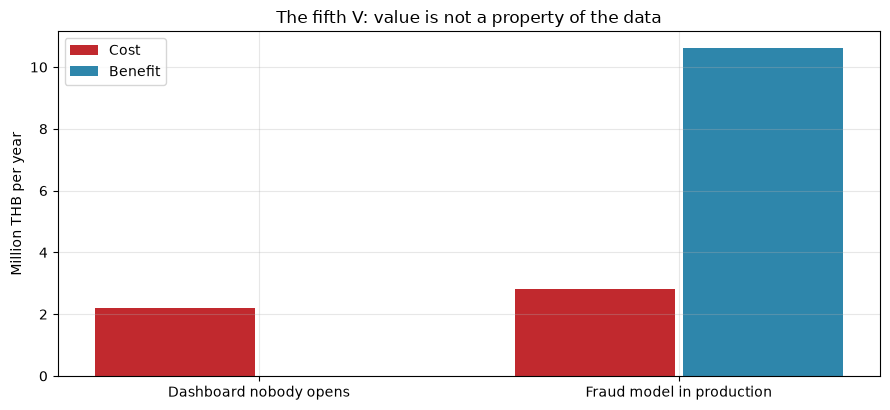

,Project,Total cost (THB),Benefit (THB),Net value (THB)
0,Dashboard nobody opens,2200000,0,-2200000
1,Fraud model in production,2800000,10625000,7825000


In [12]:
# Two projects, same data, very different value.
projects = pd.DataFrame({
    "Project": ["Dashboard nobody opens", "Fraud model in production"],
    "Storage cost / year (THB)": [400_000, 400_000],
    "Engineering cost / year (THB)": [1_800_000, 2_400_000],
    "Decisions changed / year": [0, 12_500],
    "Value per decision (THB)": [0, 850],
})
projects["Benefit (THB)"] = projects["Decisions changed / year"] * projects["Value per decision (THB)"]
projects["Total cost (THB)"] = projects["Storage cost / year (THB)"] + projects["Engineering cost / year (THB)"]
projects["Net value (THB)"] = projects["Benefit (THB)"] - projects["Total cost (THB)"]

fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(projects))
ax.bar(x - 0.2, projects["Total cost (THB)"] / 1e6, 0.38, label="Cost", color="#C1292E")
ax.bar(x + 0.2, projects["Benefit (THB)"] / 1e6, 0.38, label="Benefit", color="#2E86AB")
ax.set_xticks(x, projects["Project"])
ax.set_ylabel("Million THB per year")
ax.set_title("The fifth V: value is not a property of the data")
ax.legend()
plt.show()

projects[["Project", "Total cost (THB)", "Benefit (THB)", "Net value (THB)"]]

**How to read it:** both projects consume the same data and roughly the same money. One changes 12,500
decisions a year; the other changes none. The data was equally "big" in both cases.

**The practical test for value: name the decision.** If you cannot say which specific decision will be made
differently because of an analysis, and roughly what that difference is worth, the project has no value V — no
matter how impressive its volume is.

---
## 3. Data quality dimensions

Trust must be *measured*, not assumed. Data quality is commonly assessed against six dimensions, each catching
a different kind of "we cannot act on this yet":

| Dimension | Question | Typical check |
|---|---|---|
| **Completeness** | Is anything missing? | Fraction of non-null values per column |
| **Uniqueness** | Is anything recorded twice? | Duplicate keys |
| **Validity** | Does each value obey its rules? | Ranges, formats, allowed category lists |
| **Accuracy** | Does the value match reality? | Cross-check against a trusted source |
| **Consistency** | Do related values agree with each other? | Cross-field rules (ship date ≥ order date) |
| **Timeliness** | Is it recent enough to use? | Age of the record relative to now |

**Accuracy is the hard one.** The other five can be checked from inside the dataset. Accuracy requires
something *outside* it — another system, a physical measurement, or a person who knows. That is why so many
pipelines quietly monitor five dimensions and hope about the sixth.

Let's audit the lecture's deliberately messy order log.

In [13]:
# A deliberately messy little order log — one problem planted per dimension.
messy = pd.DataFrame({
    "order_id":   [101, 102, 103, 103, 105],
    "customer":   ["Ann", "Bo", None, "Cam", "Cam"],
    "price_baht": [120, 95, 80, 80, -50],
    "order_date": pd.to_datetime(["2026-07-01", "2026-07-02", "2026-07-02", "2026-07-02", "2020-01-01"]),
    "ship_date":  pd.to_datetime(["2026-07-03", "2026-07-04", "2026-07-05", "2026-07-05", "2019-12-28"]),
})
messy

,order_id,customer,price_baht,order_date,ship_date
0,101,Ann,120,2026-07-01,2026-07-03
1,102,Bo,95,2026-07-02,2026-07-04
2,103,NaN,80,2026-07-02,2026-07-05
3,103,Cam,80,2026-07-02,2026-07-05
4,105,Cam,-50,2020-01-01,2019-12-28


In [14]:
# Dimension 1 — COMPLETENESS: what fraction of each column is present?
completeness = messy.notna().mean()
print("Completeness per column:")
for column, value in completeness.items():
    flag = "  <-- problem" if value < 1 else ""
    print(f"  {column:12s} {value:.0%}{flag}")

# Dimension 2 — UNIQUENESS: are there duplicate keys?
duplicates = messy["order_id"].duplicated().sum()
print(f"\nUniqueness: {duplicates} duplicate order_id(s)")
if duplicates:
    repeated = messy["order_id"].value_counts()
    print("  Repeated:", repeated[repeated > 1].index.tolist())

# Dimension 3 — VALIDITY: does every value obey its rule?
invalid_price = messy["price_baht"] < 0
print(f"\nValidity: {invalid_price.sum()} price(s) below zero")
print(messy.loc[invalid_price, ["order_id", "price_baht"]].to_string(index=False))

Completeness per column:
  order_id     100%
  customer     80%  <-- problem
  price_baht   100%
  order_date   100%
  ship_date    100%

Uniqueness: 1 duplicate order_id(s)
  Repeated: [103]

Validity: 1 price(s) below zero
 order_id  price_baht
      105         -50


In [15]:
# Dimension 4 — CONSISTENCY: do related fields agree with each other?
inconsistent = messy["ship_date"] < messy["order_date"]
print(f"Consistency: {inconsistent.sum()} order(s) shipped BEFORE they were placed")
print(messy.loc[inconsistent, ["order_id", "order_date", "ship_date"]].to_string(index=False))

# Dimension 5 — TIMELINESS: how stale is each record relative to the newest one?
staleness = (messy["order_date"].max() - messy["order_date"]).dt.days
print(f"\nTimeliness: staleness in days = {staleness.tolist()}")
print(f"  Worst: order {messy.loc[staleness.idxmax(), 'order_id']} is {staleness.max():,} days behind.")

# Dimension 6 — ACCURACY: cannot be checked from inside the data.
print("\nAccuracy: NOT CHECKABLE from this table alone.")
print("  Is Ann's order really 120 baht? Only the receipt, the payment system, or Ann can say.")

Consistency: 1 order(s) shipped BEFORE they were placed
 order_id order_date  ship_date
      105 2020-01-01 2019-12-28

Timeliness: staleness in days = [1, 0, 0, 0, 2374]
  Worst: order 105 is 2,374 days behind.

Accuracy: NOT CHECKABLE from this table alone.
  Is Ann's order really 120 baht? Only the receipt, the payment system, or Ann can say.


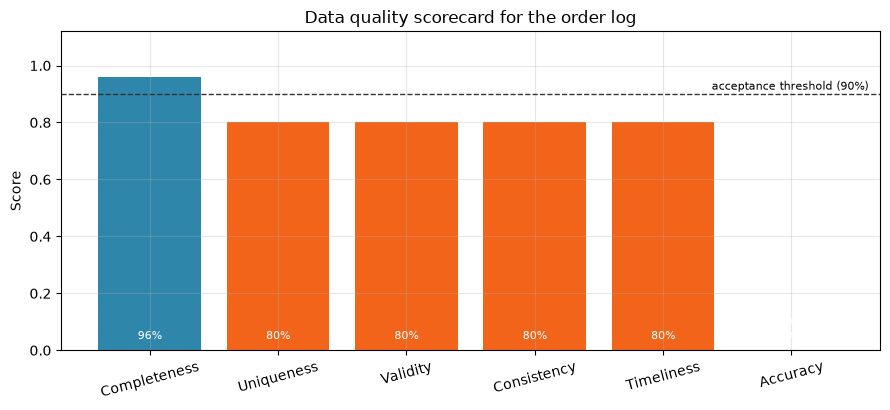

In [16]:
# Turn the audit into a scorecard, so quality becomes a number you can track over time.
scores = {
    "Completeness": messy.notna().mean().mean(),
    "Uniqueness":   1 - messy["order_id"].duplicated().mean(),
    "Validity":     1 - (messy["price_baht"] < 0).mean(),
    "Consistency":  1 - (messy["ship_date"] < messy["order_date"]).mean(),
    "Timeliness":   ((messy["order_date"].max() - messy["order_date"]).dt.days <= 30).mean(),
    "Accuracy":     np.nan,
}

fig, ax = plt.subplots(figsize=(9, 4.2))
names = list(scores.keys())
values = [0 if np.isnan(v) else v for v in scores.values()]
colors = ["#C1292E" if np.isnan(v) else ("#2E86AB" if v >= 0.9 else "#F26419")
          for v in scores.values()]
bars = ax.bar(names, values, color=colors)
ax.axhline(0.9, color="#333", linestyle="--", linewidth=1)
ax.text(len(names) - 0.4, 0.915, "acceptance threshold (90%)", fontsize=8, ha="right")
for bar, (name, value) in zip(bars, scores.items()):
    label = "not measurable\nfrom this data" if np.isnan(value) else f"{value:.0%}"
    ax.text(bar.get_x() + bar.get_width() / 2, 0.03, label,
            ha="center", va="bottom", fontsize=8,
            color="white" if not np.isnan(value) else "white")
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Data quality scorecard for the order log")
ax.tick_params(axis="x", rotation=15)
plt.show()

**How to read it:** five dimensions produce a number; the sixth cannot, and it is drawn in red precisely so
that nobody mistakes its absence for a pass. A scorecard like this is the standard way quality gets managed in
production: run it on every load, store the scores, and alert when one drops.

The subtlety worth absorbing: **the thresholds are business decisions, not statistics.** 90% completeness may
be perfectly fine for an optional survey field and a catastrophe for a payment amount. Quality is always
quality *for a purpose*.

> ✏️ **Try it:** add a seventh check for *referential integrity* — every `customer` in the order log should
> appear in a customer master list. Build a tiny master list of `["Ann", "Bo", "Cam"]` and count orders whose
> customer is not in it. Which dimension does that check belong to?

---
## 4. Big data analytics — from hindsight to foresight

The progression of analysis an organization focuses its resources on:

| Step | Stance | Question | Analytics type |
|---|---|---|---|
| 1 | **Hindsight** | What happened? | Descriptive |
| 1 | **Hindsight** | Why did it happen? | Diagnostic |
| 2 | **Insight** | What is likely to happen? | Predictive |
| 3 | **Foresight** | How can we make it happen? | Prescriptive |

Applied to one sales question:

| Type | Question |
|---|---|
| **Descriptive** | What were our sales in July 2023? |
| **Diagnostic** | Why were sales higher/lower in July 2023 vs. July 2022? |
| **Predictive** | What are our estimated sales for July 2024? |
| **Prescriptive** | What do we need to do to make sure sales are higher? |

Let's walk all four levels on six months of café sales.

In [17]:
# Six months of café sales (baht), with a second variable: promotions run each month.
sales = pd.DataFrame({
    "month": ["2025-05", "2025-06", "2025-07", "2025-08", "2025-09", "2025-10"],
    "sales_baht": [42_000, 45_500, 61_000, 58_500, 67_000, 71_500],
    "promotions_run": [1, 1, 4, 3, 4, 5],
})
sales

,month,sales_baht,promotions_run
0,2025-05,42000,1
1,2025-06,45500,1
2,2025-07,61000,4
3,2025-08,58500,3
4,2025-09,67000,4
5,2025-10,71500,5


Descriptive: July 2025 sales were 61,000 baht.
  Six-month total   : 345,500 baht
  Mean month        : 57,583 baht
  Best / worst month: 2025-10 / 2025-05


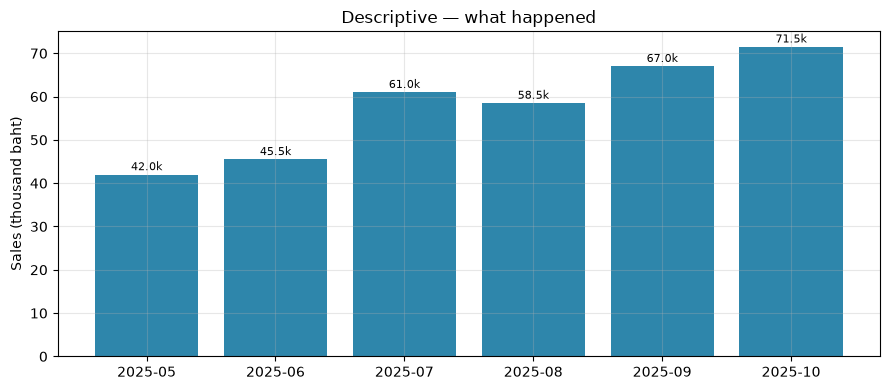

In [18]:
# LEVEL 1 — DESCRIPTIVE: "What happened?"
july_sales = sales.loc[sales["month"] == "2025-07", "sales_baht"].iloc[0]

print(f"Descriptive: July 2025 sales were {july_sales:,} baht.")
print(f"  Six-month total   : {sales['sales_baht'].sum():,} baht")
print(f"  Mean month        : {sales['sales_baht'].mean():,.0f} baht")
print(f"  Best / worst month: {sales.loc[sales['sales_baht'].idxmax(), 'month']} / "
      f"{sales.loc[sales['sales_baht'].idxmin(), 'month']}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(sales["month"], sales["sales_baht"] / 1000, color="#2E86AB")
ax.set_ylabel("Sales (thousand baht)")
ax.set_title("Descriptive — what happened")
for month, value in zip(sales["month"], sales["sales_baht"]):
    ax.text(month, value / 1000 + 1, f"{value/1000:.1f}k", ha="center", fontsize=8)
plt.show()

Diagnostic: correlation between promotions and sales = 0.98
A strong positive correlation — promotions are ASSOCIATED with higher sales.

Read the next section before you call that a cause.


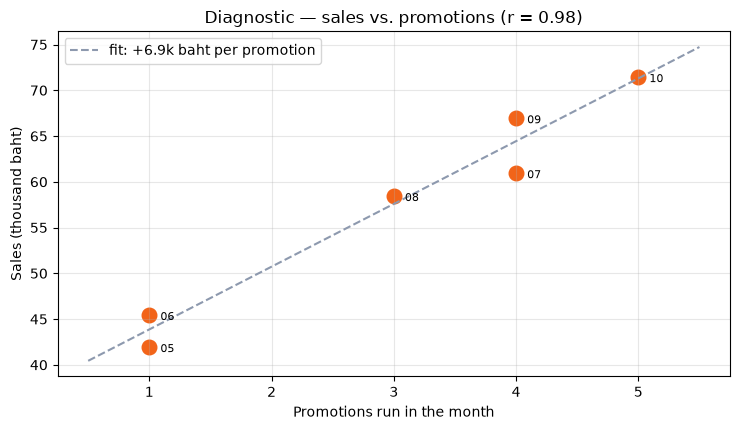

In [19]:
# LEVEL 2 — DIAGNOSTIC: "Why did it happen?"
correlation = sales["sales_baht"].corr(sales["promotions_run"])

print(f"Diagnostic: correlation between promotions and sales = {correlation:.2f}")
print("A strong positive correlation — promotions are ASSOCIATED with higher sales.")
print("\nRead the next section before you call that a cause.")

fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.scatter(sales["promotions_run"], sales["sales_baht"] / 1000, s=110, color="#F26419")
for _, row in sales.iterrows():
    ax.annotate(row["month"][-2:], (row["promotions_run"], row["sales_baht"] / 1000),
                textcoords="offset points", xytext=(8, -4), fontsize=8)
slope, intercept = np.polyfit(sales["promotions_run"], sales["sales_baht"] / 1000, 1)
grid = np.linspace(0.5, 5.5, 20)
ax.plot(grid, slope * grid + intercept, "--", color="#8D99AE",
        label=f"fit: +{slope:.1f}k baht per promotion")
ax.set_xlabel("Promotions run in the month")
ax.set_ylabel("Sales (thousand baht)")
ax.set_title(f"Diagnostic — sales vs. promotions (r = {correlation:.2f})")
ax.legend()
plt.show()

In [20]:
# LEVEL 3 — PREDICTIVE: "What is likely to happen?"
# Method A, the lecture's: average month-over-month growth, projected forward.
growth_rates = sales["sales_baht"].pct_change().dropna()
avg_growth = growth_rates.mean()
predicted_growth = sales["sales_baht"].iloc[-1] * (1 + avg_growth)

# Method B: fit a straight line through time and extend it one month.
t = np.arange(len(sales))
slope_t, intercept_t = np.polyfit(t, sales["sales_baht"], 1)
predicted_trend = slope_t * len(sales) + intercept_t

print(f"Method A — average growth ({avg_growth:.1%}/month) : {predicted_growth:>9,.0f} baht")
print(f"Method B — linear trend (+{slope_t:,.0f}/month)     : {predicted_trend:>9,.0f} baht")
print(f"\nThe two methods disagree by {abs(predicted_growth - predicted_trend):,.0f} baht "
      f"({abs(predicted_growth - predicted_trend) / predicted_trend:.1%}).")
print("Six data points cannot tell you which is right — and that gap IS the honest uncertainty.")

Method A — average growth (11.9%/month) :    80,015 baht
Method B — linear trend (+5,986/month)     :    78,533 baht

The two methods disagree by 1,482 baht (1.9%).
Six data points cannot tell you which is right — and that gap IS the honest uncertainty.


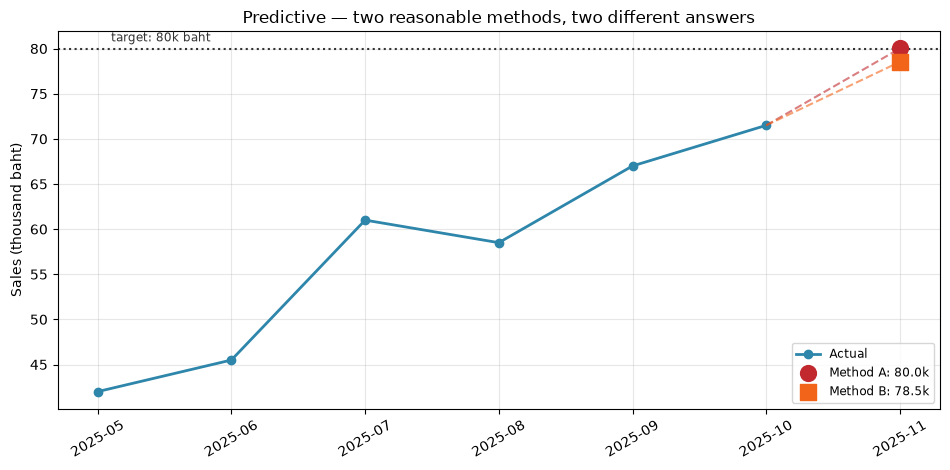

In [21]:
fig, ax = plt.subplots(figsize=(9.6, 4.8))
ax.plot(range(len(sales)), sales["sales_baht"] / 1000, marker="o", color="#2E86AB",
        linewidth=2, label="Actual")
ax.scatter([len(sales)], [predicted_growth / 1000], s=130, color="#C1292E", zorder=5,
           label=f"Method A: {predicted_growth/1000:.1f}k")
ax.scatter([len(sales)], [predicted_trend / 1000], s=130, marker="s", color="#F26419", zorder=5,
           label=f"Method B: {predicted_trend/1000:.1f}k")
ax.plot([len(sales) - 1, len(sales)], [sales["sales_baht"].iloc[-1] / 1000, predicted_growth / 1000],
        "--", color="#C1292E", alpha=0.6)
ax.plot([len(sales) - 1, len(sales)], [sales["sales_baht"].iloc[-1] / 1000, predicted_trend / 1000],
        "--", color="#F26419", alpha=0.6)
ax.axhline(80, color="#333", linestyle=":", linewidth=1.5)
ax.text(0.1, 80.8, "target: 80k baht", fontsize=8.5, color="#333")
ax.set_xticks(range(len(sales) + 1), list(sales["month"]) + ["2025-11"], rotation=30)
ax.set_ylabel("Sales (thousand baht)")
ax.set_title("Predictive — two reasonable methods, two different answers")
ax.legend(fontsize=8.5)
plt.show()

**How to read it:** the two methods differ by only about 1,500 baht — under 2% — and that small gap is
nonetheless decisive: one forecast clears the 80,000 target and the other falls short of it, so the two lead
to *different actions*. With six observations there is no way to choose between them from the data alone.

This is not a flaw in the example; it is the honest situation. **A prediction without a stated uncertainty is
a guess wearing a suit.** Chapters 8 and 10 show how to attach a real interval to a forecast rather than
quoting a single number.

In [22]:
# LEVEL 4 — PRESCRIPTIVE: "How can we make it happen?"
target = 80_000
baht_per_promotion = slope * 1000        # from the diagnostic fit, converted back to baht

for name, prediction in [("Method A (growth)", predicted_growth), ("Method B (trend)", predicted_trend)]:
    shortfall = target - prediction
    if shortfall <= 0:
        print(f"{name:20s}: predicted {prediction:>9,.0f} — already clears the target. 0 extra promotions.")
    else:
        extra = shortfall / baht_per_promotion
        print(f"{name:20s}: predicted {prediction:>9,.0f} — short by {shortfall:,.0f}, "
              f"so about {np.ceil(extra):.0f} extra promotion(s).")

print(f"\n(Using {baht_per_promotion:,.0f} baht per promotion, from the diagnostic fit.)")
print("\nCaveats a prescription must always carry:")
print("  * The fit assumes each extra promotion adds the same amount — real promotions saturate.")
print("  * It assumes promotions CAUSE sales. Section 5 explains why that is not established.")
print("  * It ignores the cost of running a promotion, which decides whether it is worth doing at all.")

Method A (growth)   : predicted    80,015 — already clears the target. 0 extra promotions.
Method B (trend)    : predicted    78,533 — short by 1,467, so about 1 extra promotion(s).

(Using 6,857 baht per promotion, from the diagnostic fit.)

Caveats a prescription must always carry:
  * The fit assumes each extra promotion adds the same amount — real promotions saturate.
  * It assumes promotions CAUSE sales. Section 5 explains why that is not established.
  * It ignores the cost of running a promotion, which decides whether it is worth doing at all.


**How to read it:** each level *builds on* the one before it — diagnostic needed descriptive's numbers,
predictive needed the trend, prescriptive needed the forecast and the fitted effect. That is why the lecture
draws it as a staircase: you cannot skip to "what should we do" without "what happened" and "why."

The most famous example of prescriptive analytics is a **recommendation engine** — Netflix or Amazon deciding
what to show a specific user next, combining many predictive models running in parallel, one per possible
recommendation. Chapter 1 built a small one from scratch.

> ✏️ **Try it:** change `target = 80000` to `150000`. Does the prescriptive recommendation still look
> reasonable? What does that tell you about extrapolating from six months of data — and about a model that
> will confidently answer any question you ask it?

---
## 5. A critical caution — correlation is not causation

Diagnostic analytics looks for **correlations**. A strong correlation does **not** prove that one variable
causes the other. The lecture's example: ice cream sales and sunburn cases correlate strongly, but ice cream
does not cause sunburn. **Hot weather causes both** — a *confounding variable*.

This matters directly for the café: Section 4 found sales correlated with promotions at r = 0.98. That is
suggestive, not proof. A confounder — a holiday season that drives both more promotions *and* more customers —
would produce exactly the same pattern.

In [23]:
# Simulate the ice-cream / sunburn / hot-weather example.
n_days = 90
temperature = rng.normal(30, 5, n_days)                                # the real cause
ice_cream_sales = 200 + 15 * temperature + rng.normal(0, 30, n_days)   # driven by temperature
sunburn_cases = 2 + 0.8 * temperature + rng.normal(0, 2, n_days)       # also driven by temperature

summer = pd.DataFrame({
    "temperature_c": temperature,
    "ice_cream_sales": ice_cream_sales,
    "sunburn_cases": sunburn_cases,
})

print("Correlation matrix:")
print(summer.corr().round(2).to_string())
print(f"\nIce cream vs. sunburn: r = {summer['ice_cream_sales'].corr(summer['sunburn_cases']):.2f}")
print("Strong — and yet ice cream does not cause sunburn.")

Correlation matrix:
                 temperature_c  ice_cream_sales  sunburn_cases
temperature_c             1.00             0.90           0.87
ice_cream_sales           0.90             1.00           0.74
sunburn_cases             0.87             0.74           1.00

Ice cream vs. sunburn: r = 0.74
Strong — and yet ice cream does not cause sunburn.


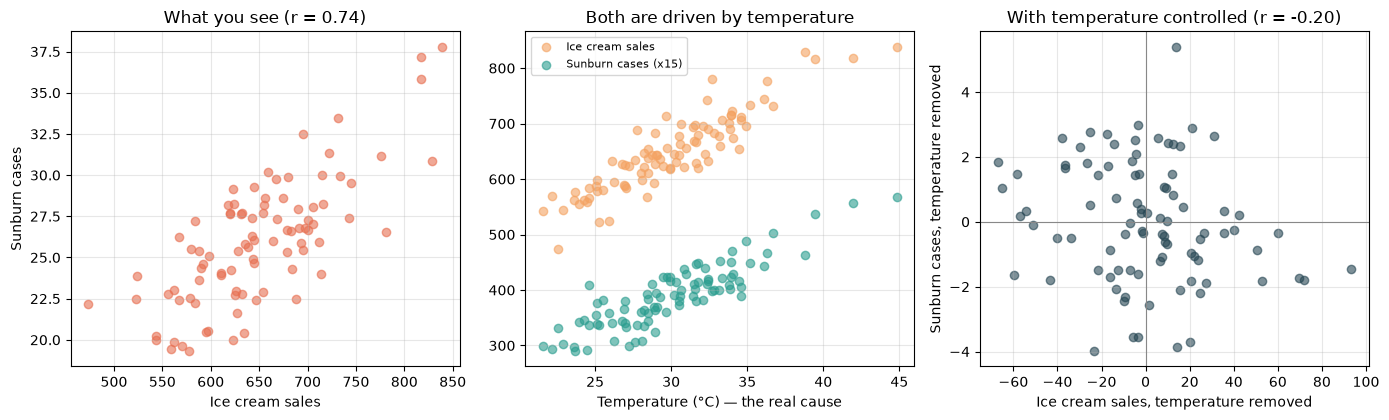

Raw correlation     : 0.745
Partial correlation : -0.203  <- the association collapses, and even changes sign


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))

r_direct = summer["ice_cream_sales"].corr(summer["sunburn_cases"])
axes[0].scatter(summer["ice_cream_sales"], summer["sunburn_cases"], alpha=0.6, color="#E76F51")
axes[0].set_xlabel("Ice cream sales")
axes[0].set_ylabel("Sunburn cases")
axes[0].set_title(f"What you see (r = {r_direct:.2f})")

axes[1].scatter(summer["temperature_c"], summer["ice_cream_sales"], alpha=0.6,
                color="#F4A261", label="Ice cream sales")
axes[1].scatter(summer["temperature_c"], summer["sunburn_cases"] * 15, alpha=0.6,
                color="#2A9D8F", label="Sunburn cases (x15)")
axes[1].set_xlabel("Temperature (°C) — the real cause")
axes[1].set_title("Both are driven by temperature")
axes[1].legend(fontsize=8)

# Remove temperature's influence from both, then correlate what is left.
ice_residual = summer["ice_cream_sales"] - np.poly1d(
    np.polyfit(summer["temperature_c"], summer["ice_cream_sales"], 1))(summer["temperature_c"])
burn_residual = summer["sunburn_cases"] - np.poly1d(
    np.polyfit(summer["temperature_c"], summer["sunburn_cases"], 1))(summer["temperature_c"])
r_partial = np.corrcoef(ice_residual, burn_residual)[0, 1]

axes[2].scatter(ice_residual, burn_residual, alpha=0.6, color="#264653")
axes[2].axhline(0, color="#888", linewidth=0.8)
axes[2].axvline(0, color="#888", linewidth=0.8)
axes[2].set_xlabel("Ice cream sales, temperature removed")
axes[2].set_ylabel("Sunburn cases, temperature removed")
axes[2].set_title(f"With temperature controlled (r = {r_partial:.2f})")

plt.show()
print(f"Raw correlation     : {r_direct:.3f}")
print(f"Partial correlation : {r_partial:.3f}  <- the association collapses, and even changes sign")

**How to read it:** the left panel is what a naive analysis sees — a clear, strong relationship (r ≈ 0.75).
The middle panel reveals the mechanism: both variables track temperature. The right panel is the diagnostic
that settles it. After statistically removing temperature's influence from both variables, the leftover
association collapses to about −0.20 — small, negative, and consistent with nothing but noise. Whatever
looked like a link between ice cream and sunburn was temperature the whole time.

That third step is called a **partial correlation**, and it is the simplest tool for testing a confounder you
have actually measured. Its limitation is severe and worth stating plainly: **it only works for confounders
you thought of and recorded.** An unmeasured confounder is invisible to every statistical test.

Whenever you find a correlation, ask three questions in order:

1. Could it be **chance**? (Section 5.2)
2. Could **something else cause both**? (a confounder — this section)
3. Could the causation run **backward**? (Do promotions raise sales, or do busy months justify promotions?)

If all three are ruled out, you have a candidate cause. The only way to actually establish it is a controlled
experiment — change the promotion schedule at random and see what happens.

### 5.1 Simpson's paradox — when a trend reverses inside every group

This is the most alarming way correlation can mislead you, because the data is not noisy, not biased, and not
mistaken. A pattern that holds in the aggregate can be the exact opposite of the pattern in every subgroup.

The café has two branches. Look at the overall relationship between promotions and sales, then look inside
each branch.

In [25]:
# Two branches: one large and busy (runs few promotions), one small and quiet (runs many).
branch_data = []
for branch, base, n_promo_mean, size in [("Nimman (busy)", 95_000, 1.2, 24),
                                         ("Suthep (quiet)", 38_000, 4.4, 24)]:
    promos = np.clip(rng.normal(n_promo_mean, 0.9, size), 0, None).round()
    # WITHIN each branch, more promotions genuinely help.
    sales_baht = base + 3_500 * promos + rng.normal(0, 2_500, size)
    branch_data.append(pd.DataFrame({"branch": branch, "promotions": promos, "sales": sales_baht}))

cafe = pd.concat(branch_data, ignore_index=True)

overall_r = cafe["promotions"].corr(cafe["sales"])
print(f"OVERALL correlation (promotions vs sales): {overall_r:+.2f}")
print("\nWITHIN each branch:")
for branch, group in cafe.groupby("branch"):
    print(f"  {branch:16s}: {group['promotions'].corr(group['sales']):+.2f}")

OVERALL correlation (promotions vs sales): -0.82

WITHIN each branch:
  Nimman (busy)   : +0.77
  Suthep (quiet)  : +0.84


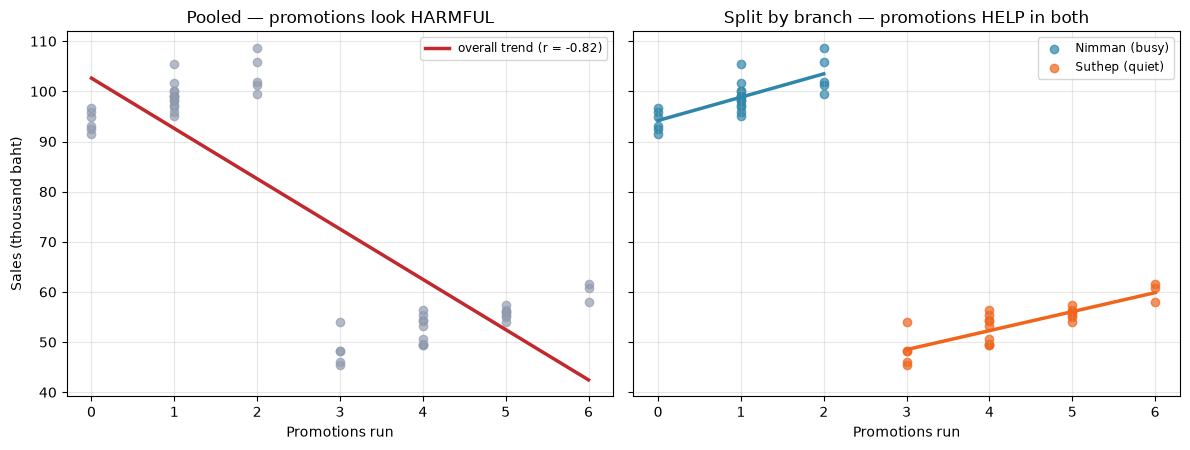

In [26]:
fig, (ax_all, ax_split) = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)

ax_all.scatter(cafe["promotions"], cafe["sales"] / 1000, alpha=0.65, color="#8D99AE")
fit_all = np.poly1d(np.polyfit(cafe["promotions"], cafe["sales"] / 1000, 1))
grid = np.linspace(cafe["promotions"].min(), cafe["promotions"].max(), 20)
ax_all.plot(grid, fit_all(grid), color="#C1292E", linewidth=2.5,
            label=f"overall trend (r = {overall_r:+.2f})")
ax_all.set_xlabel("Promotions run")
ax_all.set_ylabel("Sales (thousand baht)")
ax_all.set_title("Pooled — promotions look HARMFUL")
ax_all.legend(fontsize=8.5)

for (branch, group), color in zip(cafe.groupby("branch"), ["#2E86AB", "#F26419"]):
    ax_split.scatter(group["promotions"], group["sales"] / 1000, alpha=0.7, color=color, label=branch)
    fit = np.poly1d(np.polyfit(group["promotions"], group["sales"] / 1000, 1))
    span = np.linspace(group["promotions"].min(), group["promotions"].max(), 20)
    ax_split.plot(span, fit(span), color=color, linewidth=2.5)
ax_split.set_xlabel("Promotions run")
ax_split.set_title("Split by branch — promotions HELP in both")
ax_split.legend(fontsize=8.5)

plt.show()

**How to read it:** pooled together, more promotions go with *lower* sales — the red line slopes down. Split
by branch, more promotions go with *higher* sales in **both** branches. Both statements are arithmetically
correct on the same data.

The explanation is that branch is a confounder tangled up with promotions. The busy Nimman branch has high
sales and rarely needs promotions; the quiet Suthep branch has low sales and runs many. Pooling the two lets
that difference in *baseline* masquerade as an effect of promotions.

**The practical warning is uncomfortable: there is no way to detect this from the pooled numbers alone.** The
pooled correlation looks perfectly healthy. You find it only by asking "what groups are in this data, and
should I be looking within them?" — which is a domain question, not a statistical one.

> ✏️ **Try it:** change the Suthep branch's `base` from `38_000` to `90_000`, so the two branches have similar
> baselines, and re-run. Does the paradox survive? What does that tell you about the condition that creates
> it?

### 5.2 Spurious correlation — chance alone produces impressive numbers

Before blaming a confounder, rule out chance. With few observations, high correlations happen constantly for
no reason at all — and with many variables, some pair is nearly *guaranteed* to correlate strongly.

n =   6: |r| exceeds 0.5 in 32.1% of trials from PURE NOISE
n =  30: |r| exceeds 0.5 in 0.5% of trials from PURE NOISE
n = 200: |r| exceeds 0.5 in 0.0% of trials from PURE NOISE


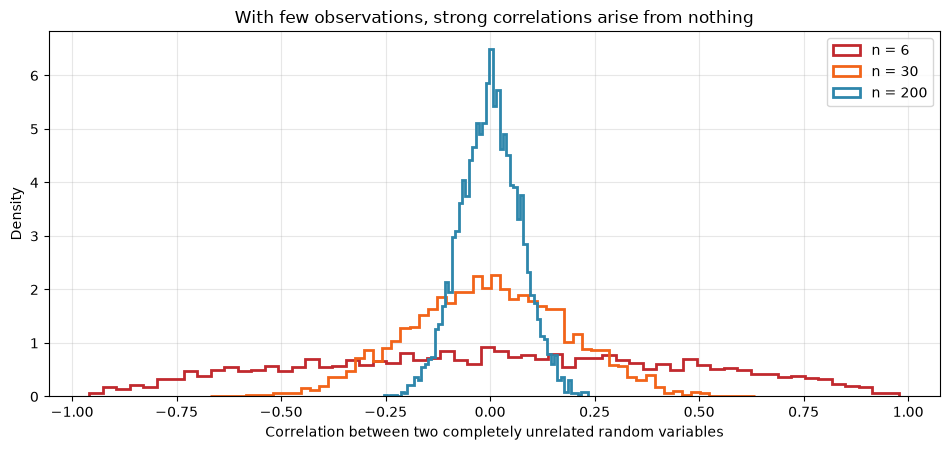

In [27]:
# How large a correlation should you expect from pure noise?
fig, ax = plt.subplots(figsize=(9.6, 4.6))

for n_points, color in [(6, "#C1292E"), (30, "#F26419"), (200, "#2E86AB")]:
    correlations = [np.corrcoef(rng.normal(size=n_points), rng.normal(size=n_points))[0, 1]
                    for _ in range(4_000)]
    ax.hist(correlations, bins=60, histtype="step", linewidth=2, density=True,
            color=color, label=f"n = {n_points}")
    print(f"n = {n_points:>3}: |r| exceeds 0.5 in "
          f"{np.mean(np.abs(correlations) > 0.5):.1%} of trials from PURE NOISE")

ax.set_xlabel("Correlation between two completely unrelated random variables")
ax.set_ylabel("Density")
ax.set_title("With few observations, strong correlations arise from nothing")
ax.legend()
plt.show()

**How to read it:** with only 6 observations — exactly the café dataset's size — two entirely unrelated
random variables produce |r| > 0.5 in a large fraction of trials. The distribution is wide. With 200
observations it collapses to a narrow spike near zero, and a correlation of 0.5 becomes genuinely surprising.

So the café's r = 0.98 across six months is **less impressive than it looks**, and this reframes Section 4's
diagnostic step honestly: the correlation is a hypothesis worth testing, not a finding.

The companion problem is **multiple comparisons**. Test enough pairs of variables and something will correlate
strongly by chance alone.

In [28]:
# Twenty unrelated variables, all pure noise. How strong is the strongest pair?
n_vars, n_obs = 20, 40
noise = pd.DataFrame(rng.normal(size=(n_obs, n_vars)),
                     columns=[f"v{i:02d}" for i in range(n_vars)])

corr = noise.corr().abs().to_numpy(copy=True)
np.fill_diagonal(corr, 0)
corr = pd.DataFrame(corr, index=noise.columns, columns=noise.columns)
strongest = corr.stack().idxmax()
n_pairs = n_vars * (n_vars - 1) // 2

print(f"{n_vars} variables of pure noise -> {n_pairs} distinct pairs.")
print(f"Strongest correlation found: {strongest[0]} vs {strongest[1]} = {corr.loc[strongest]:.2f}")
print(f"Pairs with |r| > 0.3: {(corr.to_numpy()[np.triu_indices(n_vars, 1)] > 0.3).sum()} of {n_pairs}")
print("\nNone of these variables has anything to do with any other. Not one.")

20 variables of pure noise -> 190 distinct pairs.
Strongest correlation found: v08 vs v17 = 0.44
Pairs with |r| > 0.3: 10 of 190

None of these variables has anything to do with any other. Not one.


**How to read it:** searching 190 pairs of pure noise turns up a respectable-looking correlation, and several
moderate ones. If you go looking through a wide dataset for "interesting relationships," this is what you will
find first — and it will look exactly like a discovery.

The defense is procedural rather than statistical: **decide what you are testing before you look**, and treat
anything found by scanning as a hypothesis to be confirmed on fresh data. This is the same discipline that
Chapter 10 formalizes as keeping a test set you do not touch.

---
## 6. Where the V's send you architecturally

Each V pushes you toward particular technology, which is the bridge to Chapter 5. Worth knowing the vocabulary
now, even though the tools come later.

| Pressure | Consequence | Typical technology |
|---|---|---|
| **Volume** | One machine is not enough | Distributed storage and compute (HDFS, Spark, cloud object storage) |
| **Velocity** | Cannot wait for a nightly batch | Stream processing (Kafka, Flink, Spark Streaming) |
| **Variety** | It does not fit in rows and columns | Document/NoSQL stores, data lakes, object storage |
| **Veracity** | Errors must be caught, not discovered later | Validation and monitoring in the pipeline |
| **Value** | Analysis must reach a decision-maker | BI tools, dashboards, model serving |

### Data warehouse vs. data lake

The distinction is the most common architectural question in the field, and it is really a question about
*when* you impose structure.

| | **Data warehouse** | **Data lake** |
|---|---|---|
| Stores | Cleaned, modeled, structured data | Raw data in its original form |
| Schema | **On write** — defined before loading | **On read** — imposed when you query |
| Strength | Fast, reliable, trustworthy queries | Flexible; keeps everything, including what you did not know you needed |
| Weakness | Rigid; a new question may need a schema change | Can decay into a "data swamp" nobody can navigate |
| Suits | Known, repeated business questions | Exploration, machine learning, unstructured data |

**Schema-on-write** means you decide the structure before the data arrives, and reject anything that does not
fit. **Schema-on-read** means you store whatever arrives and figure out the structure when you query it.

Neither is correct in general. Warehouses fail when the questions change faster than the schema; lakes fail
when nobody documents what is in them. Most organizations end up with both, plus a "lakehouse" layer trying to
give the lake some of the warehouse's guarantees.

In [29]:
# The trade-off, made concrete: what happens when a new field appears?
print("A new field 'loyalty_tier' starts arriving in the source system.\n")

print("SCHEMA-ON-WRITE (warehouse):")
print("  1. The load fails, or the field is silently dropped.")
print("  2. Someone changes the table definition.")
print("  3. The pipeline is updated and redeployed.")
print("  4. Data from before the change does not have the field — and never will.")
print("  Result: slow to adapt, but the table always means exactly what it claims to.\n")

print("SCHEMA-ON-READ (lake):")
print("  1. The field lands in storage immediately. Nothing breaks.")
print("  2. Old records simply lack the key; new ones have it.")
print("  3. Every query must now handle its absence.")
print("  Result: fast to adapt, but the burden moves to everyone who reads it — forever.")

records_before = [{"id": 1, "spend": 240}, {"id": 2, "spend": 180}]
records_after = [{"id": 3, "spend": 300, "loyalty_tier": "gold"},
                 {"id": 4, "spend": 150, "loyalty_tier": "silver"}]

lake = pd.json_normalize(records_before + records_after)
print("\nWhat the lake holds afterwards:")
print(lake.to_string(index=False))
print("\nThe NaNs are not errors. They are the history of a schema change, preserved.")

A new field 'loyalty_tier' starts arriving in the source system.

SCHEMA-ON-WRITE (warehouse):
  1. The load fails, or the field is silently dropped.
  2. Someone changes the table definition.
  3. The pipeline is updated and redeployed.
  4. Data from before the change does not have the field — and never will.
  Result: slow to adapt, but the table always means exactly what it claims to.

SCHEMA-ON-READ (lake):
  1. The field lands in storage immediately. Nothing breaks.
  2. Old records simply lack the key; new ones have it.
  3. Every query must now handle its absence.
  Result: fast to adapt, but the burden moves to everyone who reads it — forever.

What the lake holds afterwards:
 id  spend loyalty_tier
  1    240          NaN
  2    180          NaN
  3    300         gold
  4    150       silver

The NaNs are not errors. They are the history of a schema change, preserved.


---
## 7. Glossary

| Term | Meaning |
|---|---|
| **Big data** | Data at a scale where traditional storage, processing, or analysis tools stop working |
| **Volume** | How much data there is |
| **Velocity** | How fast new data arrives, and how fast a response is needed |
| **Variety** | The diversity of forms: structured, semi-structured, unstructured |
| **Veracity** | The trustworthiness of the data |
| **Value** | Whether analysis produces a decision worth more than its cost |
| **Structured data** | Fixed schema; fits a relational table |
| **Semi-structured data** | Self-describing tags, flexible schema (JSON, XML) |
| **Unstructured data** | No schema at all: text, images, audio, video |
| **Batch / micro-batch / stream** | Process periodically / in small windows / record by record |
| **Latency** | The delay between an event and the response to it |
| **Completeness / uniqueness / validity** | Nothing missing / nothing duplicated / values obey their rules |
| **Accuracy / consistency / timeliness** | Matches reality / fields agree / recent enough to use |
| **Descriptive / diagnostic** | What happened / why it happened — hindsight |
| **Predictive** | What is likely to happen — insight |
| **Prescriptive** | What action to take — foresight |
| **Correlation** | A statistical association between two variables |
| **Confounder** | An unmeasured third variable that causes both of two correlated variables |
| **Partial correlation** | The association that remains after removing a measured confounder |
| **Simpson's paradox** | A trend that reverses when the data is split into subgroups |
| **Spurious correlation** | A strong association arising from chance alone |
| **Data warehouse / data lake** | Structured on write / raw on write, structured on read |

---
## 8. Check your understanding

**Q1.** A hospital stores 40 TB of X-ray images. Which V is most demanding here, and why is it not volume?

<details><summary>Answer</summary>

Variety. 40 TB is large but entirely manageable with ordinary storage. The hard part is that an X-ray image
has no rows and columns — extracting anything analyzable from it requires computer vision, which is a
different class of problem from "the file is big."
</details>

**Q2.** A bank has a perfectly clean, complete, well-modeled warehouse of every transaction for ten years, and
has never used it for anything. Which V is it failing?

<details><summary>Answer</summary>

Value. It scores well on volume, veracity, and variety, and none of that matters. Value is the only V that is
about what you *do*, and the test is: name the decision that gets made differently.
</details>

**Q3.** Ten million rows arrive daily and 4% of the `customer_id` values are blank. Does more data help?

<details><summary>Answer</summary>

No. That is a veracity (specifically completeness) problem, and it is a *rate*, not a count. Ten times more
data gives you ten times more blanks in the same proportion. Volume never fixes veracity.
</details>

**Q4.** Which of these needs stream processing rather than a nightly batch: (a) the monthly payroll, (b)
blocking a fraudulent card transaction, (c) a quarterly board report?

<details><summary>Answer</summary>

Only (b). The value of a fraud decision decays within seconds — after the transaction completes, the money is
gone. Payroll and board reports are not more valuable if computed sooner, so they do not justify the cost of
streaming.
</details>

**Q5.** You find that customers who use the mobile app spend 3× more than those who do not, and conclude the
app causes higher spending. What are the two competing explanations?

<details><summary>Answer</summary>

**Reverse causation** — customers who already spend a lot are the ones motivated enough to install the app.
And a **confounder** — loyal, high-income customers both install apps and spend more, with the app doing
nothing. Only a randomized experiment (encourage a random subset to install it) separates these.
</details>

**Q6.** Overall, a training course is associated with *lower* exam scores. Within every department, trainees
score *higher* than non-trainees. What is going on, and which conclusion should you act on?

<details><summary>Answer</summary>

Simpson's paradox. Departments with historically weaker results probably enrolled far more people in training,
so the pooled comparison is dominated by that difference in baseline rather than by the training. Act on the
within-department comparison, because department is a confounder that the pooled number ignores.
</details>

**Q7.** With 6 monthly observations you find r = 0.98. How impressed should you be?

<details><summary>Answer</summary>

Cautiously. Section 5.2 showed that with n = 6, unrelated noise produces |r| > 0.5 remarkably often. A high
correlation on very few points is a hypothesis, not a finding — check it on more data before building a
prescription on it.
</details>

**Q8.** Your team wants to store clickstream logs whose future use is unknown. Warehouse or lake?

<details><summary>Answer</summary>

Lake. Schema-on-write requires you to decide the structure now, and you do not know the questions yet. The
cost is that someone must document what is there, or the lake becomes a swamp within a year.
</details>

**Q9.** Which data quality dimension cannot be checked from inside the dataset, and what does that imply?

<details><summary>Answer</summary>

Accuracy — whether a value matches reality — requires an external reference: another system, a physical
measurement, or a person who knows. It implies that a green quality dashboard is never proof the data is
*right*, only that it is internally well-formed.
</details>

---
## 9. Summary — key takeaways

1. **Big data is a scale problem, not a size.** Not just "a lot of data" — data at a scale where traditional
   tools break, relative to your tools and your question.
2. **Volume, velocity, variety, veracity** — four characteristics that define what makes data genuinely big.
   Each names a *different reason* the ordinary approach fails, and only the first two are about size.
3. **Value is the fifth V**, and the only one the organization cares about. It is a property of what you do,
   not of the data. Name the decision.
4. **Velocity is a business question in disguise.** How fast does the answer rot? That, not the technology,
   decides batch versus stream.
5. **Variety is where the work is.** Most enterprise data is unstructured, and it is the form that is hardest
   to use.
6. **Volume never fixes veracity.** A million wrong rows is worse than a thousand right ones, because it is
   more convincing. And the dangerous errors are the *plausible* ones, which no validation rule catches.
7. **Trust must be measured.** Completeness, uniqueness, validity, consistency, and timeliness are all
   checkable. Accuracy is not — it needs a source outside the data.
8. **Analytics has four levels.** Descriptive and diagnostic (hindsight), predictive (insight), prescriptive
   (foresight) — each builds on the last, and you cannot skip.
9. **A prediction without an uncertainty is a guess wearing a suit.** Two defensible methods on the same six
   points disagreed by thousands of baht.
10. **Correlation ≠ causation.** Before believing an association, rule out chance, a confounder, and reverse
    causation — and remember that Simpson's paradox can flip a trend that looks entirely healthy.

### Where this goes next

- **Chapter 4 — Business Problems and Data Science Solutions**: turning the value V into a defined problem.
- **Chapter 5 — Tools for Data Analytics**: the technology the V's push you toward.
- **Chapter 6 — Data Preparation**: fixing, in practice, what Section 3 audited.
- **Chapter 8 — Statistics and Probability**: how to attach honest uncertainty to Section 4's forecast.
- **Chapter 12 — Text Mining**: attacking the unstructured majority from Section 2.3.

### Further reading

The lecture's own sources:

1. *Open data is the new oil that fuels society* — ONS Digital.
2. *Big data basics: understanding big data* — Businesstechweekly.com.
3. *5 V's of big data* — GeeksforGeeks.
4. *Evolution of telecoms: from 1G to 5G* (infographic); *Comparison of 2G/3G/4G/5G* — RantCell.
5. *Meet the data quality dimensions*; *Data quality dimensions* — DATAVERSITY.
6. *4 levels of data analytics maturity*; Christensen, A. (2022). *What is analytics maturity framework?*
7. *Predictive analytics: what's possible, who's doing it, and how.*
8. *What is prescriptive analytics? 6 examples* — HBS Online.

Beyond the slides:

9. Laney, D. (2001). *3D data management: controlling data volume, velocity and variety* — the paper that
   started the V's.
10. Simpson, E. H. (1951). *The interpretation of interaction in contingency tables* — the paradox in
    Section 5.1.
11. Vigen, T. *Spurious Correlations* — an entertaining catalog of exactly what Section 5.2 simulates.

## 10. Homework 📝

### 👤 Student information

**Name:**  *(double-click to edit this cell and fill in your name)*

**Student ID:**

**Date:**

### The homework dataset — ☕ Campus Café order log

Run the cell below to generate a small, deliberately messy order log from a campus café over 40 orders.
**Do not modify it** — everyone's numbers must match.

In [30]:
# ------- RUN THIS CELL, BUT DO NOT MODIFY IT -------
hw_rng = np.random.default_rng(888102)
n = 40

order_id = list(range(3001, 3001 + n))
# Inject a few duplicate order_ids on purpose
order_id[10] = order_id[9]
order_id[25] = order_id[24]

customer = hw_rng.choice(["Ploy", "Nan", "Beam", "Kong", "Mai", None], size=n, p=[0.19, 0.19, 0.19, 0.19, 0.19, 0.05])
price_baht = np.round(hw_rng.uniform(35, 120, n), 0)
# Inject a couple of invalid prices
price_baht[3] = -20
price_baht[17] = 9999

order_date = pd.to_datetime("2026-07-01") + pd.to_timedelta(hw_rng.integers(0, 20, n), unit="D")
# Inject one very stale record
order_date_list = list(order_date)
order_date_list[30] = pd.Timestamp("2023-01-15")

promotions_active = hw_rng.integers(0, 4, n)

cafe = pd.DataFrame({
    "order_id": order_id,
    "customer": customer,
    "price_baht": price_baht,
    "order_date": order_date_list,
    "promotions_active": promotions_active,
})
cafe.head(10)

,order_id,customer,price_baht,order_date,promotions_active
0,3001,Beam,98.0,2026-07-07,3
1,3002,Mai,75.0,2026-07-08,3
2,3003,Beam,108.0,2026-07-19,3
3,3004,Kong,-20.0,2026-07-06,2
4,3005,Kong,106.0,2026-07-08,2
5,3006,Mai,52.0,2026-07-03,2
6,3007,Mai,75.0,2026-07-12,1
7,3008,Kong,53.0,2026-07-19,0
8,3009,Beam,37.0,2026-07-20,1
9,3010,Ploy,50.0,2026-07-01,1


---

### Exercise 1 — Which V's apply?

Considering the full `cafe` dataset (40 rows) and how it was collected in real life (continuously, as
customers order): which of the four V's (Volume, Velocity, Variety, Veracity) are most relevant to this
scenario, and why? *(Volume doesn't have to be "big" in absolute terms to discuss the concept — reason about
what would happen if this café had 40 *million* orders a day instead of 40.)*

In [31]:
# YOUR CODE HERE (Exercise 1)
# (Written analysis -- you can leave this cell empty or use it for scratch work.)


**✍️ Your answer to Question 1:** *(double-click to edit)*

---

### Exercise 2 — Completeness and uniqueness

Compute the **completeness** (fraction of non-missing values) of each column in `cafe`. Then find how many
**duplicate** `order_id` values exist, and print the full rows involved.

In [32]:
# YOUR CODE HERE (Exercise 2)


**✍️ Your answer to Question 2:**

---

### Exercise 3 — Validity

Prices should realistically fall between 20 and 300 baht for this café. Find all rows where `price_baht`
falls **outside** that range, and report what fraction of all orders are invalid by this rule.

In [33]:
# YOUR CODE HERE (Exercise 3)


**✍️ Your answer to Question 3:**

---

### Exercise 4 — Timeliness

Using the most recent `order_date` in the dataset as "today," compute how many days old every record is.
Flag any record more than **60 days** old as "stale." How many stale records are there, and which one(s)?

In [34]:
# YOUR CODE HERE (Exercise 4)


**✍️ Your answer to Question 4:**

---

### Exercise 5 — Climb the analytics maturity ladder

Using `cafe` (you may want to drop invalid/stale rows first, using your answers above), answer one question
at each level:

1. **Descriptive:** What was the total revenue (sum of `price_baht`) across all valid orders?
2. **Diagnostic:** Is there a correlation between `promotions_active` and `price_baht`? Compute it.
3. **Predictive/Prescriptive:** Based on the correlation you found, would you recommend the café run *more* or
   *fewer* promotions to increase average order value? Justify in one sentence.

In [35]:
# YOUR CODE HERE (Exercise 5)


**✍️ Your answer to Question 5:**

---

### Exercise 6 — Structured, semi-structured, or unstructured?

The café also stores (a) its order log as a spreadsheet, (b) each customer's loyalty-app profile as JSON with
a `favorite_drinks` list, and (c) photos customers post on social media tagging the café. Classify each of the
three as structured, semi-structured, or unstructured, and explain in one sentence why each would be
progressively harder to analyze automatically.

In [36]:
# YOUR CODE HERE (Exercise 6)
# (Written analysis -- you can leave this cell empty or use it for scratch work.)


**✍️ Your answer to Question 6:**

---

### Bonus — Correlation vs. causation

Suppose the café owner notices: "on days with more `promotions_active`, we also see higher foot traffic from
a nearby event venue." They conclude "promotions cause more foot traffic." Using the ice-cream/sunburn
reasoning from Section 5, propose one possible **confounding variable** that could explain both trends without
promotions directly causing foot traffic.

In [37]:
# YOUR CODE HERE (Bonus)


**✍️ Your answer to the bonus question:**

---

### ✅ Submission checklist

- [ ] Filled in your student information above
- [ ] Ran the dataset cell without modifying it
- [ ] Answered all 6 exercises plus the bonus
- [ ] Notebook runs top-to-bottom without errors (Kernel → Restart & Run All)
- [ ] Saved and submitted the `.ipynb` file